## **LightGBM Classifier**

## Import Libraries

In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time

In [48]:
df = pd.read_csv('main_clean_data.csv')

In [49]:
df.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,1.395524,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,...,1,0,0,0,1,1,0,0,0,0
1,-1.314686,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,...,1,0,0,0,1,0,0,0,0,1
2,0.130760,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,...,0,0,1,0,0,0,0,0,0,1
3,0.311440,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,...,1,0,0,1,0,0,0,1,0,0
4,0.311440,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,...,0,1,1,0,0,1,0,0,0,0


# Features and Target


In [50]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop('completion_status', axis=1)

y = df['completion_status']

##  Train Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [52]:
# ==========================================================
# LightGBM Classifier
# ==========================================================

start_time = time.time()

lgbm_clf = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1

)

lgbm_clf.fit(
    X_train,
    y_train
)

end_time = time.time()

print(
    "Training Time :",
    round(end_time-start_time,3),
    "seconds"
)

Training Time : 0.118 seconds


In [53]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = lgbm_clf.predict(
    X_test
)

## LightGBM Accuracy

In [54]:
# ==========================================================
# Accuracy
# ==========================================================

lgbm_acc = accuracy_score(
    y_test,
    y_pred
)

print(
    "LightGBM Accuracy :",
    lgbm_acc
)

LightGBM Accuracy : 0.8244013683010262


## Classification Report

In [55]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.87      0.86      0.86       564
         1.0       0.75      0.76      0.76       313

    accuracy                           0.82       877
   macro avg       0.81      0.81      0.81       877
weighted avg       0.82      0.82      0.82       877



## Confusion Matrix

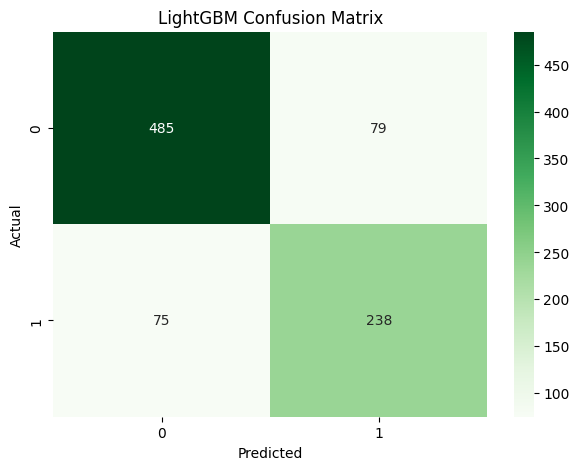

In [56]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "LightGBM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC AUC Score


In [57]:
# ==========================================================
# ROC AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score

# Probability for Positive Class
y_prob = lgbm_clf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score :{auc_score:.4f}")

ROC-AUC Score :0.9077


# ROC Curve


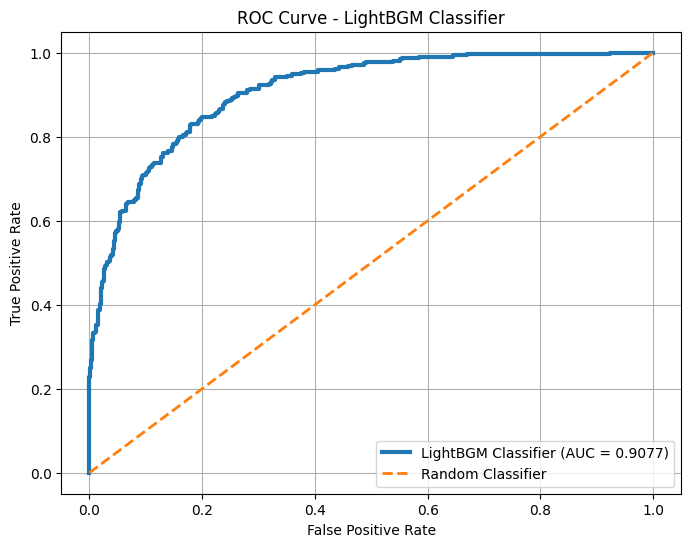

In [58]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'LightBGM Classifier (AUC = {auc_score:.4f})'
)

# Random Classifier Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - LightBGM Classifier"
)

plt.legend()

plt.grid(True)

plt.show()

## **LightGBM Regressor**

## Import Libraries

In [59]:
# ==========================================================
# Import Regressor
# ==========================================================

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Features and Target


In [60]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop(
    'final_score',
    axis=1
)

y = df['final_score']

## Train Test Split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [62]:
# ==========================================================
# LightGBM Regressor
# ==========================================================

start_time = time.time()

lgbm_reg = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgbm_reg.fit(
    X_train,
    y_train
)

end_time = time.time()

print(
    "Training Time :",
    round(end_time-start_time,3),
    "seconds"
)

Training Time : 0.091 seconds


In [63]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = lgbm_reg.predict(
    X_test
)

## Regression Metrics

In [64]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 6.4634487544169845
MSE : 64.49906949957392
RMSE : 8.031131271469414
R2 Score : 0.625057670973729


# Actual vs Predicted


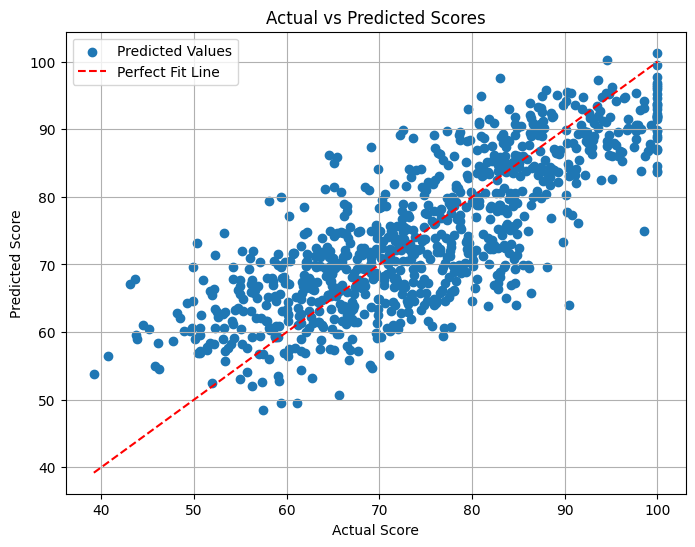

In [65]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    label="Predicted Values"
)

# Perfect Fit Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Scores")

plt.legend()

plt.grid(True)

plt.show()

# LightGBM Classifier Analysis

## Overview

LightGBM (Light Gradient Boosting Machine) is a highly efficient gradient boosting framework that uses histogram-based learning and leaf-wise tree growth. It is designed to provide faster training speed, lower memory consumption, and high predictive performance.

In this project, LightGBM Classifier was implemented to predict student course completion status.

---

## Training Performance

### Training Time

**Training Time = 0.118 Seconds**

The model completed training extremely quickly, demonstrating the computational efficiency of LightGBM. Compared to traditional boosting algorithms, LightGBM significantly reduces training time while maintaining strong predictive performance.

---

## Classification Results

### Accuracy Score

**Accuracy = 82.44%**

The LightGBM Classifier correctly predicted approximately 82 out of every 100 student completion outcomes.

---

## Classification Report

| Class | Precision | Recall | F1-Score |
|---------|---------|---------|---------|
| 0 (Not Completed) | 0.87 | 0.86 | 0.86 |
| 1 (Completed) | 0.75 | 0.76 | 0.76 |

### Macro Average

- Precision: 0.81
- Recall: 0.81
- F1-Score: 0.81

### Weighted Average

- Precision: 0.82
- Recall: 0.82
- F1-Score: 0.82

---

## Interpretation

- The model achieved strong classification performance across both classes.
- Students who did not complete the course were predicted with high accuracy.
- The completed class also showed balanced precision and recall values.
- The F1-scores indicate stable classification performance.
- LightGBM provided competitive accuracy while requiring very little training time.

---

## ROC-AUC Analysis

### ROC-AUC Score

**ROC-AUC = 0.9077**

The ROC-AUC score measures the model's ability to distinguish between completed and non-completed students.

### Interpretation

| AUC Score | Performance |
|------------|------------|
| 0.50 | Poor |
| 0.60 - 0.70 | Fair |
| 0.70 - 0.80 | Good |
| 0.80 - 0.90 | Very Good |
| Above 0.90 | Excellent |

The obtained ROC-AUC score of **0.9077** indicates excellent classification capability and strong class separation performance.

---

## LightGBM Classifier Conclusion

The LightGBM Classifier achieved an accuracy of **82.44%** and an excellent **ROC-AUC score of 0.9077**. Despite its extremely short training time of only **0.118 seconds**, the model delivered strong predictive performance. These results demonstrate that LightGBM is an efficient and reliable classification algorithm for educational outcome prediction.

---

# LightGBM Regressor Analysis

## Overview

LightGBM Regressor extends the LightGBM framework to regression problems by sequentially learning residual errors and improving prediction accuracy. The model is optimized for speed and scalability while maintaining strong predictive capability.

The objective was to predict student final scores based on academic and engagement-related features.

---

## Regression Results

| Metric | Value |
|----------|----------|
| MAE | 6.46 |
| MSE | 64.50 |
| RMSE | 8.03 |
| R² Score | 0.6251 |

---

### Mean Absolute Error (MAE)

**MAE = 6.46**

On average, the predicted score differs from the actual score by approximately 6.46 marks.

---

### Mean Squared Error (MSE)

**MSE = 64.50**

The average squared prediction error is relatively low, indicating good predictive performance.

---

### Root Mean Squared Error (RMSE)

**RMSE = 8.03**

The model's predictions deviate from actual scores by approximately 8.03 marks on average.

---

### R² Score

**R² Score = 0.6251**

This indicates that approximately **62.51% of the variation in student final scores** is explained by the LightGBM Regressor model.

---

## Interpretation

- The model captured a substantial portion of the relationship between input features and final scores.
- Prediction errors remained within an acceptable range.
- The R² score demonstrates good explanatory power and predictive capability.
- LightGBM successfully balanced prediction accuracy and computational efficiency.

---

## LightGBM Regressor Conclusion

The LightGBM Regressor achieved an **R² score of 0.6251**, indicating that the model explains approximately **62.51% of the variance** in student final scores. With an **MAE of 6.46** and **RMSE of 8.03**, the model produced reliable and accurate score predictions. The results demonstrate that LightGBM is an effective regression algorithm for educational analytics tasks.

---

# Final LightGBM Summary

LightGBM proved to be an efficient and powerful ensemble learning technique for both classification and regression tasks.

### Classification Performance

- Accuracy: **82.44%**
- ROC-AUC Score: **0.9077**
- Weighted F1-Score: **0.82**
- Training Time: **0.118 Seconds**

### Regression Performance

- R² Score: **62.51%**
- MAE: **6.46**
- RMSE: **8.03**

### Overall Conclusion

LightGBM delivered strong predictive performance while maintaining exceptional training efficiency. The classifier achieved excellent discrimination capability with a ROC-AUC score above 0.90, while the regressor explained over 62% of the variation in student scores. The extremely fast training time makes LightGBM particularly suitable for large-scale machine learning applications. Therefore, LightGBM is an effective and computationally efficient ensemble learning algorithm for predicting student course completion status and final academic performance in the Smart Outcome Predictor project.
```**``**